In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import joblib

In [2]:
# ==============================
# 2. LOAD DATA
# ==============================
PROJECT_PATH = Path.cwd().parent
DATA_PATH = PROJECT_PATH / "data" / "train_FD001.csv"

print("Dataset path :", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("✅ Data loaded")
df.head()

Dataset path : c:\Users\venut\OneDrive\Documents\Projects\predictive_maintenance\data\train_FD001.csv
✅ Data loaded


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [3]:
# ==============================
# 3. VERIFY TARGET (RUL)
# ==============================
# RUL should already exist from Notebook 1
print(df[["engine_id", "cycle", "RUL"]].head())

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187


In [4]:
# ==============================
# 4. RUL CAPPING (IMPORTANT)
# ==============================
RUL_CAP = 125
df["RUL"] = df["RUL"].clip(upper=RUL_CAP)

print("✅ RUL capping applied")

✅ RUL capping applied


In [5]:
# ==============================
# 5. FEATURE SELECTION (DYNAMIC)
# ==============================
sensor_cols = [col for col in df.columns if col.startswith("sensor")]

sensor_variance = df[sensor_cols].std()

low_variance_sensors = sensor_variance[sensor_variance < 0.01].index.tolist()

print("Dropping low variance sensors:", low_variance_sensors)

feature_cols = df.drop(
    columns=["engine_id", "cycle", "RUL"] + low_variance_sensors
).columns

Dropping low variance sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [6]:
# ==============================
# 6. TRAIN-TEST SPLIT (BY ENGINE)
# ==============================
engine_ids = df["engine_id"].unique()

train_engines, test_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["engine_id"].isin(train_engines)]
test_df  = df[df["engine_id"].isin(test_engines)]

X_train = train_df[feature_cols]
y_train = train_df["RUL"]

X_test = test_df[feature_cols]
y_test = test_df["RUL"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16561, 17)
Test shape: (4070, 17)


In [7]:
# ==============================
# 7. LINEAR MODELS (PIPELINE)
# ==============================
models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso())
    ])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{name} Performance:")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)
    
    results.append([name, rmse, mae, r2])


Linear Performance:
RMSE: 20.433002476007502
MAE : 16.513482736490335
R2  : 0.76008015351854

Ridge Performance:
RMSE: 20.43303767046886
MAE : 16.5134987904673
R2  : 0.7600793270264914



Lasso Performance:
RMSE: 20.560987301916853
MAE : 16.62160723633204
R2  : 0.7570652010475822


In [8]:
# ==============================
# 8. RANDOM FOREST MODEL
# ==============================
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance:")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)
print("R2  :", r2_rf)

results.append(["Random Forest", rmse_rf, mae_rf, r2_rf])


Random Forest Performance:
RMSE: 17.06176110428332
MAE : 12.465874463518306
R2  : 0.8327178841010485


In [9]:
# ==============================
# 9. CROSS VALIDATION (GroupKFold)
# ==============================
groups = train_df["engine_id"]

cv = GroupKFold(n_splits=5)

scores = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    groups=groups
)

print(f"\nRandom Forest CV RMSE: {-scores.mean():.2f}")


Random Forest CV RMSE: 19.03


In [10]:
# ==============================
# 10. HYPERPARAMETER TUNING
# ==============================
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_final = best_model.predict(X_test)

print("\nFinal Tuned Random Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))
print("MAE :", mean_absolute_error(y_test, y_pred_final))
print("R2  :", r2_score(y_test, y_pred_final))

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Final Tuned Random Forest
RMSE: 17.026376197308565
MAE : 12.43347393653027
R2  : 0.8334110275584359


In [11]:
# ==============================
# 11. MODEL COMPARISON
# ==============================
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])

print("\nModel Comparison:")
print(results_df.sort_values(by="RMSE"))


Model Comparison:
           Model       RMSE        MAE        R2
3  Random Forest  17.061761  12.465874  0.832718
0         Linear  20.433002  16.513483  0.760080
1          Ridge  20.433038  16.513499  0.760079
2          Lasso  20.560987  16.621607  0.757065


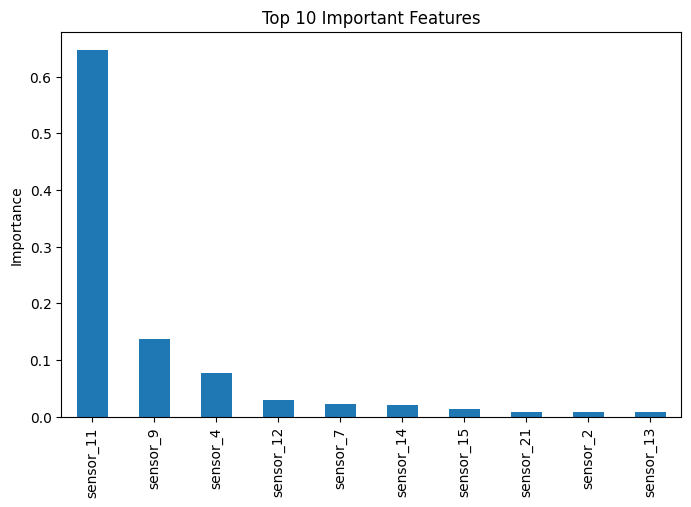

In [12]:
# ==============================
# 12. FEATURE IMPORTANCE
# ==============================
importances = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()

In [13]:
# ==============================
# 13. SAVE MODEL
# ==============================
MODEL_PATH = PROJECT_PATH / "models"
MODEL_PATH.mkdir(exist_ok=True)

joblib.dump(best_model, MODEL_PATH / "rf_rul_model.pkl")
joblib.dump(list(feature_cols), MODEL_PATH / "feature_columns.pkl")

print("✅ Model and feature columns saved successfully")

✅ Model and feature columns saved successfully
